# <span style="color:red"> QTM 151 - Quiz 5 </span>

### Submit as an **HTML file**
### Quiz is open 11:30am to 12:20pm

<font size = "4" >
This quiz is open book 

- You can use the lecture notes
- You will get partial credit for attempting the questions
- To get full credit, the code should work as intended
- You should <span style="color:red"> NOT </span> communicate with other students

Print the following message: <br>

"I will abide by Emory's code of conduct"

In [1]:
# Write your answer here

print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
yelp = pd.read_csv("yelp_reviews.csv")
yelp.head()

,url,rating,date,review
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...


<font size = "5">

1. Replacing strings

<font size = "4">

- Read in the data from "yelp_reviews.csv", assigning the output to a DataFrame.

- This dataset contains a large number of restaurant reviews from yelp.com. The text of each review is stored in the "review" column.

- In the "review" column, do the following:

    - Replace all instances of the word "champaign" with "Champaign" (it is a proper noun, the name of a city in Illinois)
    - Replace all instances of the phrase "Champaign Urbana" with "Champaign-Urbana".

- Make sure the replacements you make are being applied to the original DataFrame.


In [45]:
# your code here
yelp = pd.read_csv("yelp_reviews.csv")
yelp.head()
yelp["review"] = yelp["review"].str.replace("champaign", "Champaign")
yelp["review"] = yelp["review"].str.replace("Champaign Urbana", "Champaign-Urbana")
yelp.head()


,url,rating,date,review
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...


<font size = "5">

2. Look for reviews containing a string pattern

<font size = "4">

- Search for all reviews that contain a string describing a range of years, such as "1992-1998" or "2000-2007".

- Create a DataFrame called ``df_year`` that consists of all the rows of the original DataFrame for which you found a range of years in the Yelp review.

- We can characterize a range of years as: 4 digit characters, followed by a dash, followed by 4 digit characters.


In [38]:
# your code here
df_year = yelp[yelp["review"].str.contains("\d\d\d\d-\d\d\d\d")]
df_year.head()

,url,rating,date,review
12240,https://www.yelp.com/biz/prestis-bakery-cleveland,5,9/7/2008,Lived in Cleveland Heights for 5 years (1987-1...
14737,https://www.yelp.com/biz/jarlings-custard-cup-...,4,8/18/2009,"On a journey to revisit my mom's college town,..."
17759,https://www.yelp.com/biz/masons-creamery-cleve...,5,10/2/2016,Very yummy vegan ice creams. The moment you st...


<font size = "5">

3. Find similarly spelled words

<font size = "4">

- Find all occurences of the words "place", "places", "plate", and "plates" in the reviews by using ``.str.findall`` **one time**. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)

In [46]:
# your code here
yelp["matches"] = yelp["review"].str.findall("(places?|plates?)")
yelp_with_matches = yelp[yelp["matches"].str.len() > 0]
yelp_with_matches.head()

,url,rating,date,review,matches
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...,[place]
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...,[places]
5,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,5/1/2019,I've been coming to this ice cream stand since...,[place]
6,https://www.yelp.com/biz/sidney-dairy-barn-sidney,1,8/11/2016,The soft-serve is way too sweet and has a stra...,[place]
7,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,11/5/2016,My husband and I stopped here on the way back ...,[place]


<font size = "5">

4. Find words ending with "y"

<font size = "4">

- Find all words ending with the letter "y" by using ``.str.findall``. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Specifically, you are looking for one or more consecutive alphabetical characters (both upper and lower case) or apostrophe (single quote) characters followed by the letter "y".

- In order to ensure that the word **ends** with "y", add the special character "\\\b" (two backslashes and a "b") immediately after the "y". This is called a word boundary.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)



In [40]:
# your code here
yelp["ends_with_y"] = yelp["review"].str.findall("[a-zA-Z']*y\\b")
yelp_y_words =yelp[yelp["ends_with_y"].str.len() > 0]
yelp_y_words.head()


,url,rating,date,review,matches,ends_with_y
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...,[],"[say, they, very, very]"
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...,[place],"[My, My, usually]"
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...,[],"[day, very, friendly]"
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...,[],"[freshly, only, pretty, icy]"
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...,[places],"[my, really, easy, Dairy, very, friendly, many..."


<font size = "5">

5. Convert reviews to individual words

<font size = "4">

- Add a new column to the DataFrame with the name "tokens", where each row of the column is a list containing all individual words appearing in the Yelp review for that row.

- For the purposes of this question, we will take a single word to be one or more consecutive occurrences of the letters, A-Z, a-z, and the apostrophe character.

- Then use ``.apply`` to ensure every word in the "tokens" column is lowercase. Make sure you are actually changing the "tokens" column of the DataFrame in this step.

- **Note:** There are no "NaNs" in the "review" column, so it shouldn't be necessary to account for the case where an entry in the "tokens" column isn't actually a list.

In [49]:
# your code here
yelp["tokens"] = yelp["review"].str.findall("[A-Za-z']+")
def lower_list(lst):
    out = []
    if not isinstance(lst, list):
        return tuple(out)
    for w in lst:
        out.append(w.lower())
    return tuple(out)

yelp["tokens"] = yelp["tokens"].apply(lower_list)
yelp.head()


,url,rating,date,review,matches,tokens
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...,[],"(all, i, can, say, is, they, have, very, good,..."
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...,[place],"(nice, little, local, place, for, ice, cream, ..."
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...,[],"(a, delicious, treat, on, a, hot, day, staff, ..."
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...,[],"(this, was, great, service, and, a, fun, crew,..."
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...,[places],"(this, is, one, of, my, favorite, places, to, ..."


<font size = "5">

6. Convert reviews to individual words

<font size = "4">

- Unravel the values from "tokens" into a single Pandas Series containing all the words appearing in every review.

- Then, create a new Pandas Series containing the probabilities/proportions of each word. This Pandas Series will have an index column (the tokens/words) and the single "proper" column will be the proportions/probabilities.

- Create a bar plot of the probabilities of the 13 most frequently occuring words in the dataset. Add a label to the y-axis and a title.

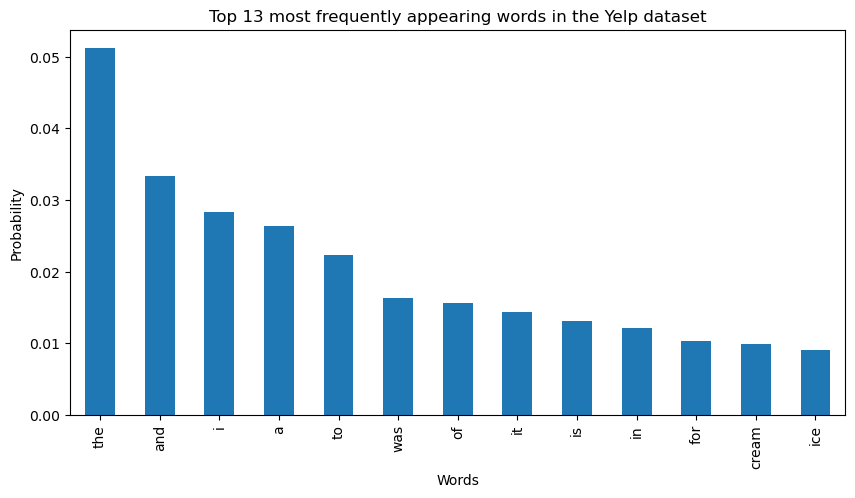

In [50]:
# your code here
yelp_appearances = yelp["tokens"].explode()
yelp_counts = yelp_appearances.value_counts()
yelp_prob = yelp_counts / yelp_counts.sum()
top_yelp = yelp_prob.head(13)
top_yelp.plot(kind="bar", figsize=(10,5))
plt.title("Top 13 most frequently appearing words in the Yelp dataset")
plt.ylabel("Probability")
plt.xlabel("Words")
plt.show()

In [53]:
yelp_prob.head(13)

tokens
the      0.051181
and      0.033378
i        0.028268
a        0.026318
to       0.022372
was      0.016261
of       0.015601
it       0.014410
is       0.013125
in       0.012075
for      0.010340
cream    0.009860
ice      0.009021
Name: count, dtype: float64